# QC evidence: testing the claims behind `QC_EXCLUDE_STATIONS` / `QC_MASK_DATE_RANGES`

This notebook *derives* the evidence behind the station-cleaning rules in
`LAND_AS/s1_prepare/config.py`, which `LAND_AS/s1_prepare/load_raw.py` applies
at load time. It reads the **raw** daily CSVs (pre-cleaning) so excluded
stations are visible here. Nothing is taken as given — each section states a
claim and the code either confirms or refutes it:

1. `aunuu`: does it report strictly in 0.1-inch steps, and does the co-located
   `aunuu_UH` cover the same site?
2. `vaipito2000`: implausible early era? biased low vs. co-located gauges?
   or a duplicated record of the same site?
3. `afono_UH`: do flat-zero runs exist, do they match the configured mask
   windows, and did the nearest stations share them?
4. `pioa_afono`: accumulation signature vs. real dry weeks (audited, retained).

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
PACKAGE_DIR = Path.cwd()
if not (PACKAGE_DIR / "config.py").exists():
    if (PACKAGE_DIR / "LAND_AS").exists():
        PACKAGE_DIR = PACKAGE_DIR / "LAND_AS"
    elif (PACKAGE_DIR.parent / "config.py").exists():
        PACKAGE_DIR = PACKAGE_DIR.parent
REPO_ROOT = PACKAGE_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from LAND_AS.s1_prepare import config as prep_config  # QC rules live here

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "font.size": 9})
FIG_DIR = PACKAGE_DIR / "output" / "figures" / "qc_evidence"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAIN_DIR = REPO_ROOT / "raw_data" / "AS" / "final_rainfall_per_station"
daily = {}
for f in sorted(RAIN_DIR.glob("*.csv")):
    d = pd.read_csv(f)
    col = "precip_in" if "precip_in" in d.columns else "precip_mm"
    scale = 25.4 if col == "precip_in" else 1.0
    s = pd.to_numeric(d[col], errors="coerce") * scale
    s.index = pd.to_datetime(d["datetime"], format="%m/%d/%Y")
    daily[f.stem] = s.rename("rain_mm").sort_index()

def weekly_totals(s):
    """Sum daily values over complete ISO weeks only."""
    d = s.dropna()
    iso = d.index.isocalendar()
    wk = iso["year"].astype(str) + "-W" + iso["week"].astype(str).str.zfill(2)
    g = d.groupby(wk)
    return g.sum()[g.size() == 7]

print("loaded", len(daily), "station files")
print("QC_EXCLUDE_STATIONS:", sorted(prep_config.QC_EXCLUDE_STATIONS))
print("QC_MASK_DATE_RANGES:", prep_config.QC_MASK_DATE_RANGES)

loaded 28 station files
QC_EXCLUDE_STATIONS: ['afono_UH', 'aunuu']
QC_MASK_DATE_RANGES: {}


## 0. Whole-network survey

Every station's record is characterised the same way before singling any of
them out: span, daily/weekly zero rates, minimum nonzero daily value, and the
fraction of nonzero values sitting exactly on 0.1-inch (2.54 mm) multiples.
The last two columns expose coarse reporting resolution network-wide — not
just for the excluded stations.

                     first        last  n_days  daily_zero%  weekly_zero%  min_nonzero  %mult_2.54        qc
station                                                                                                     
aunuu           1997-04-02  2002-07-10    1231        58.81         12.43         2.54      100.00  excluded
satala          1997-12-11  2008-10-05    3534        37.52          3.28         0.25       86.01          
vaipito_res     1989-10-01  2008-10-05    4327        39.61          3.52         0.25       83.89          
fagaitua        1997-12-12  2008-10-05    3497        44.30          4.30         0.25       81.78          
aoloafou        2000-06-30  2008-10-05    2219        35.29          2.34         0.25       80.08          
malaeimi_1691   1990-08-31  2008-10-05    6013        45.07          2.14         0.25       70.97          
aasufou80       1980-01-01  2000-06-06    7225        46.73          1.80         0.25       48.14          
pioa_afono      198

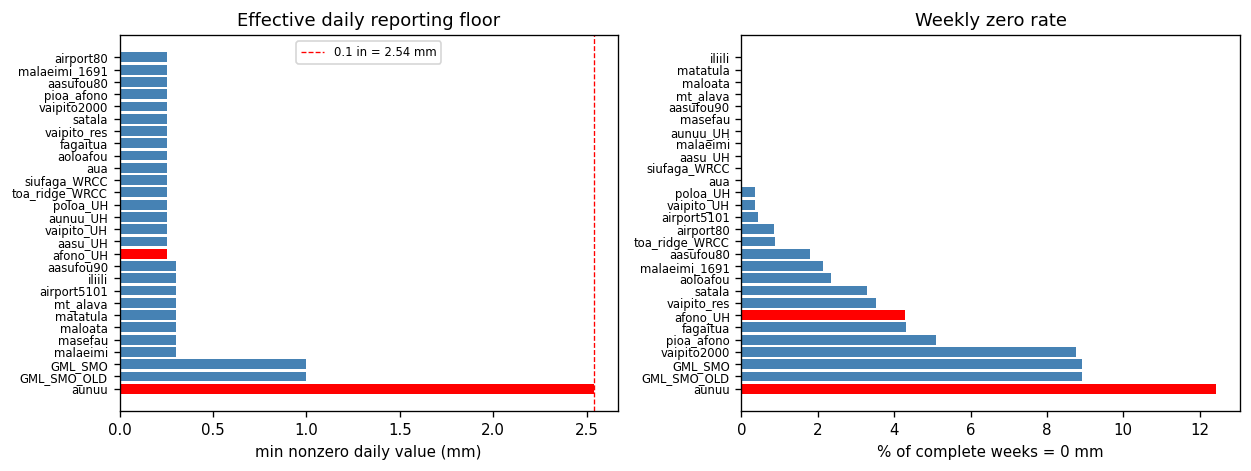

In [2]:
rows = []
for name, s in sorted(daily.items()):
    d = s.dropna()
    nz = d[d > 0]
    wk = weekly_totals(d)
    rows.append({
        "station": name,
        "first": d.index.min().date(), "last": d.index.max().date(),
        "n_days": len(d),
        "daily_zero%": 100 * (d <= 0).mean(),
        "weekly_zero%": 100 * (wk <= 0).mean() if len(wk) else np.nan,
        "min_nonzero": nz.min() if len(nz) else np.nan,
        "%mult_2.54": 100 * np.isclose(nz / 2.54, np.round(nz / 2.54), atol=1e-3).mean() if len(nz) else np.nan,
        "qc": ("excluded" if name in prep_config.QC_EXCLUDE_STATIONS else
               ("masked" if name in prep_config.QC_MASK_DATE_RANGES else "")),
    })
survey = pd.DataFrame(rows).set_index("station").sort_values("%mult_2.54", ascending=False)
print(survey.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
survey_sorted = survey.sort_values("min_nonzero", ascending=False)
colors = survey_sorted["qc"].map({"excluded": "red", "masked": "orange"}).fillna("steelblue")
axes[0].barh(range(len(survey_sorted)), survey_sorted["min_nonzero"], color=colors)
axes[0].set_yticks(range(len(survey_sorted)), survey_sorted.index, fontsize=7)
axes[0].axvline(2.54, color="red", ls="--", lw=0.8, label="0.1 in = 2.54 mm")
axes[0].set_xlabel("min nonzero daily value (mm)"); axes[0].legend(fontsize=7)
axes[0].set_title("Effective daily reporting floor")

survey_z = survey.sort_values("weekly_zero%", ascending=False)
colors_z = survey_z["qc"].map({"excluded": "red", "masked": "orange"}).fillna("steelblue")
axes[1].barh(range(len(survey_z)), survey_z["weekly_zero%"], color=colors_z)
axes[1].set_yticks(range(len(survey_z)), survey_z.index, fontsize=7)
axes[1].set_xlabel("% of complete weeks = 0 mm")
axes[1].set_title("Weekly zero rate")
fig.tight_layout()
fig.savefig(FIG_DIR / "whole_network_survey.png")
plt.show()

## 1. `aunuu`: does it report strictly in 0.1-inch steps?

Claim under test: if the gauge only reports in 0.1-inch steps, its smallest
nonzero daily value should be 2.54 mm, most/all nonzero values should be
exact multiples of it, and drizzle days (< ~1.3 mm) will read as zero —
inflating the zero rate. The comparison gauge is `aunuu_UH`, a modern
higher-resolution record for the same site; if the co-located record exists,
excluding `aunuu` loses no unique location.

        aunuu: n= 1231  min_nonzero=  2.54 mm  %mult(2.54mm)=100.0  daily_zero%= 58.8  weekly_zero%= 12.4
     aunuu_UH: n=  366  min_nonzero=  0.25 mm  %mult(2.54mm)=  6.8  daily_zero%= 36.1  weekly_zero%=  0.0
  vaipito2000: n= 9724  min_nonzero=  0.25 mm  %mult(2.54mm)= 37.3  daily_zero%= 52.4  weekly_zero%=  8.8
   pioa_afono: n= 5063  min_nonzero=  0.25 mm  %mult(2.54mm)= 45.6  daily_zero%= 50.9  weekly_zero%=  5.1


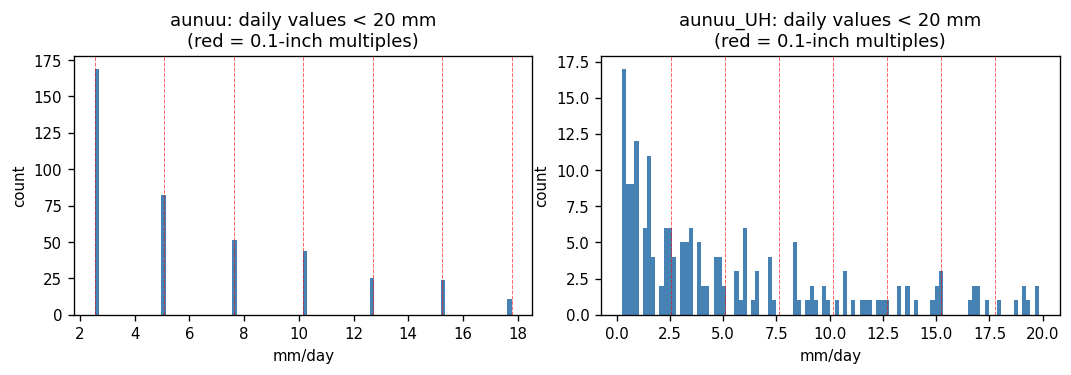

In [3]:
for name in ["aunuu", "aunuu_UH", "vaipito2000", "pioa_afono"]:
    d = daily[name].dropna()
    nz = d[d > 0]
    wk = weekly_totals(d)
    print(f"{name:>13}: n={len(d):5d}  min_nonzero={nz.min():6.2f} mm  "
          f"%mult(2.54mm)={100*np.isclose(nz / 2.54, np.round(nz / 2.54), atol=1e-3).mean():5.1f}  "
          f"daily_zero%={100 * (d <= 0).mean():5.1f}  weekly_zero%={100 * (wk <= 0).mean():5.1f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, name in zip(axes, ["aunuu", "aunuu_UH"]):
    nz = daily[name].dropna()
    nz = nz[(nz > 0) & (nz < 20)]
    ax.hist(nz, bins=100, color="steelblue", edgecolor="none")
    for k in range(1, 8):
        ax.axvline(2.54 * k, color="red", lw=0.6, ls="--", alpha=0.6)
    ax.set_title(f"{name}: daily values < 20 mm\n(red = 0.1-inch multiples)")
    ax.set_xlabel("mm/day"); ax.set_ylabel("count")
fig.tight_layout()
fig.savefig(FIG_DIR / "aunuu_reporting_floor.png")
plt.show()

## 2. `vaipito2000`: collapse, bias, or duplication?

Four competing explanations are tested below:

1. Is the early era (1958–69, mean ~3-4x its own later mean) corroborated by
   *any* nearby station, and is it internally consistent (daily cadence,
   reporting grid)?
2. Is the early era even physically plausible?
3. Is the record biased low relative to the co-located `vaipito_res` /
   `vaipito_UH` gauges — or is that an era-confounded comparison?
4. Where `vaipito2000` and `vaipito_res` overlap in time, do they record
   independent rainfall or the same site?

### 2a. The 1958–69 block: corroborated by any neighbour? internally plausible?

The early era's mean (~23-30 mm/day) is far above every other station-era
mean in the network. Two checks, both derived rather than assumed:

1. **Corroboration**: does *any* station record overlap 1958–69? Scan every
   per-station CSV *and* `raw_data/AS/daily_wide_4302025.csv` for pre-1970
   coverage.
2. **Internal structure**: if the early values were weekly totals misfiled
   as daily, nonzero readings should cluster on one weekday and gaps
   between wet days should pile up at ~7 days. If they are genuine daily
   readings, cadence should be uniform. Also check the value grid — the
   early block's reporting resolution tells us which instrument produced it.

Pre-1970 coverage, per-station CSVs:
      vaipito2000: 1958-07-01..1969-12-31  n=2507

Pre-1970 coverage, daily_wide_4302025.csv (all station rows):
      vaipito2000: n=2507

vaipito2000 1958-1969: n=2507, mean=17.1 mm/day, zero%=37.3, max=315.0
  %mult(0.05in=1.27mm)=99.5   %mult(0.1in)=68.1
  weekday of nonzero: [233, 221, 218, 222, 226, 224, 229]
  gap-days between nonzero: [1074, 232, 95, 62, 31]

vaipito2000 1970-1991: n=7217, mean=5.7 mm/day, zero%=57.6, max=155.2
  %mult(0.05in=1.27mm)=37.9   %mult(0.1in)=21.4
  weekday of nonzero: [623, 513, 525, 483, 474, 212, 227]
  gap-days between nonzero: [1606, 389, 405, 187, 164]

vaipito2000 yearly (pre-1970): n_days / mean mm/day
          size  mean
datetime            
1958        80  29.1
1959       217  30.0
1960       117  24.7
1961       288  18.4
1962       361  20.3
1963       350  13.9
1964       364  15.5
1965       365  13.9
1969       365   8.1


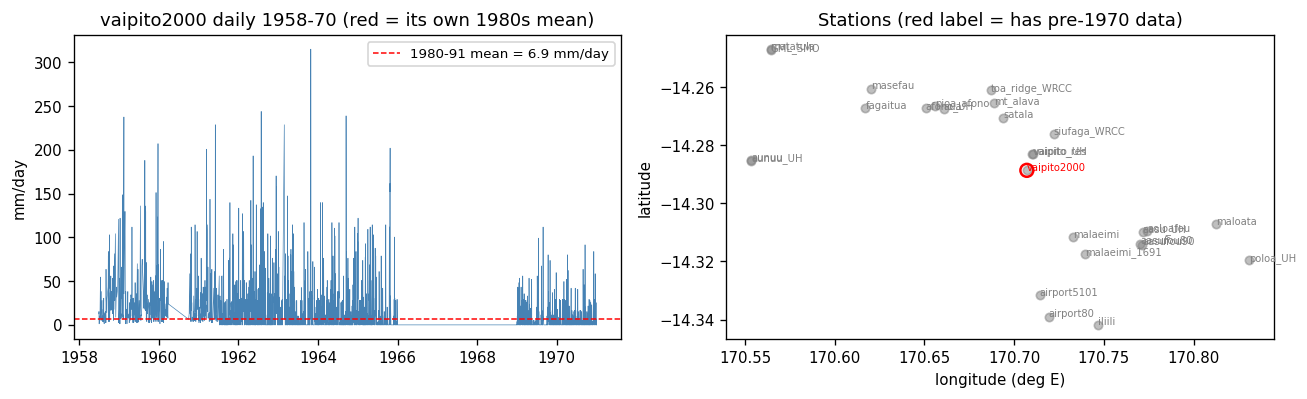

In [4]:
# (1) Is vaipito2000 the ONLY pre-1970 record? Scan every source.
print("Pre-1970 coverage, per-station CSVs:")
for name, s in sorted(daily.items()):
    pre = s.dropna().loc[:"1969-12-31"]
    if len(pre):
        print(f"  {name:>15}: {pre.index.min().date()}..{pre.index.max().date()}  n={len(pre)}")

wide = pd.read_csv(REPO_ROOT / "raw_data" / "AS" / "daily_wide_4302025.csv")
date_cols = [c for c in wide.columns if "/" in c]
dts = pd.to_datetime(date_cols, format="%m/%d/%Y")
pre_cols = [c for c, t in zip(date_cols, dts) if t.year < 1970]
sub = wide.set_index("station_name")[pre_cols]
print("\nPre-1970 coverage, daily_wide_4302025.csv (all station rows):")
for nm, cnt in sub.notna().sum(axis=1).pipe(lambda s: s[s > 0]).items():
    print(f"  {nm:>15}: n={cnt}")

# (2) Internal structure of vaipito2000's own early block vs later era
v = daily["vaipito2000"].dropna()
for label, sl in [("1958-1969", slice("1958", "1969")),
                  ("1970-1991", slice("1970", "1991"))]:
    e = v.loc[sl]
    nz = e[e > 0]
    m05 = np.isclose(nz / 1.27, np.round(nz / 1.27), atol=1e-3).mean()
    gaps = nz.index.to_series().diff().dt.days.dropna()
    print(f"\nvaipito2000 {label}: n={len(e)}, mean={e.mean():.1f} mm/day, "
          f"zero%={100*(e<=0).mean():.1f}, max={e.max():.1f}")
    print(f"  %mult(0.05in=1.27mm)={100*m05:.1f}   %mult(0.1in)="
          f"{100*np.isclose(nz/2.54, np.round(nz/2.54), atol=1e-3).mean():.1f}")
    print("  weekday of nonzero:", nz.index.dayofweek.value_counts().sort_index().tolist())
    print("  gap-days between nonzero:", gaps.value_counts().sort_index().head(5).tolist())

# yearly mean of the early block + map of where every station sits
early = v.loc[:"1969"].groupby(v.loc[:"1969"].index.year).agg(["size", "mean"])
print("\nvaipito2000 yearly (pre-1970): n_days / mean mm/day")
print(early.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(v.loc["1958":"1970"].index, v.loc["1958":"1970"].values, lw=0.4,
             color="steelblue")
axes[0].axhline(v.loc["1980":"1991"].mean(), color="red", ls="--", lw=0.9,
                label=f"1980-91 mean = {v.loc['1980':'1991'].mean():.1f} mm/day")
axes[0].set_title("vaipito2000 daily 1958-70 (red = its own 1980s mean)")
axes[0].set_ylabel("mm/day"); axes[0].legend(fontsize=8)

meta2 = pd.read_csv(REPO_ROOT / "raw_data" / "AS" / "station_locations.csv")
first = {n: s.dropna().index.min() for n, s in daily.items()}
axes[1].scatter(-meta2["LONG"], meta2["LAT"], s=25, color="grey", alpha=0.5)
for _, r in meta2.iterrows():
    pre70 = first.get(r.Station, pd.Timestamp("9999")) < pd.Timestamp("1970")
    axes[1].annotate(r.Station, (-r.LONG, r.LAT), fontsize=6,
                     color="red" if pre70 else "grey")
axes[1].scatter(-meta2.loc[meta2.Station == "vaipito2000", "LONG"],
                meta2.loc[meta2.Station == "vaipito2000", "LAT"],
                s=60, facecolor="none", edgecolor="red", lw=1.5)
axes[1].set_title("Stations (red label = has pre-1970 data)")
axes[1].set_xlabel("longitude (deg E)"); axes[1].set_ylabel("latitude")
fig.tight_layout()
fig.savefig(FIG_DIR / "vaipito2000_pre1970.png")
plt.show()


vaipito2000 by decade:
             n  zero_pct  median   mean
datetime                               
1950       297      0.00   19.05  29.78
1960      2210     42.26    5.08  15.40
1970      3501     61.27    0.00   4.38
1980      3121     51.14    0.00   7.19
1990       595     70.42    0.00   5.63

vaipito_res by decade:
             n  zero_pct  median   mean
datetime                               
1980        92     58.70    0.00   8.26
1990      1610     46.52    2.54   9.95
2000      2625     34.70    2.54  13.05

vaipito_UH by decade:
             n  zero_pct  median   mean
datetime                               
2010       204     31.37    2.29   9.75
2020      1806     19.77    3.81  11.94

Daily overlap: 244 days, 1989-10-01..1990-09-29
  v2k  mean=5.70 mm/day, zero%=67
  vres mean=5.70 mm/day, zero%=67
  weekly overlap: 33 weeks, corr=1.0000, identical rows=100%


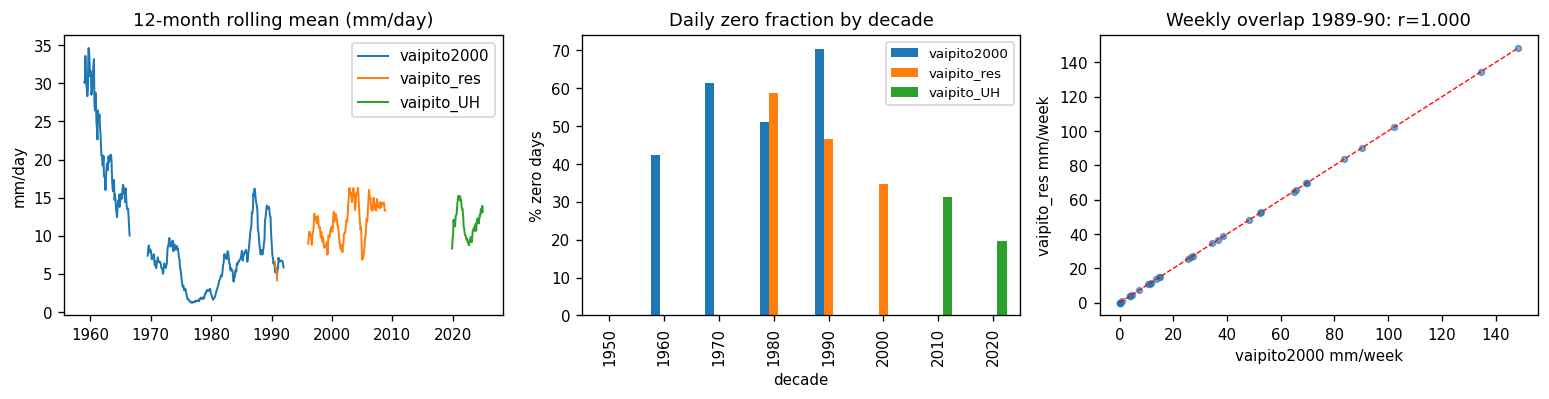

In [5]:
names = ["vaipito2000", "vaipito_res", "vaipito_UH"]
dec = {}
for name in names:
    d = daily[name].dropna()
    dec[name] = d.groupby(d.index.year // 10 * 10).agg(
        n="size", zero_pct=lambda x: 100 * (x <= 0).mean(),
        median="median", mean="mean")
    print(f"\n{name} by decade:")
    print(dec[name].round(2).to_string())

# decisive check: overlap window vaipito2000 vs vaipito_res
j = pd.concat([daily["vaipito2000"].rename("v2k"),
               daily["vaipito_res"].rename("vres")], axis=1).dropna()
jw = pd.concat([weekly_totals(daily["vaipito2000"]).rename("v2k"),
                weekly_totals(daily["vaipito_res"]).rename("vres")], axis=1).dropna()
print(f"\nDaily overlap: {len(j)} days, {j.index.min().date()}..{j.index.max().date()}")
print(f"  v2k  mean={j.v2k.mean():.2f} mm/day, zero%={100*(j.v2k<=0).mean():.0f}")
print(f"  vres mean={j.vres.mean():.2f} mm/day, zero%={100*(j.vres<=0).mean():.0f}")
print(f"  weekly overlap: {len(jw)} weeks, corr={jw.v2k.corr(jw.vres):.4f}, "
      f"identical rows={100 * np.isclose(jw.v2k, jw.vres).mean():.0f}%")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for name in names:
    d = daily[name].dropna()
    roll = d.resample("ME").mean().rolling(12, min_periods=6).mean()
    axes[0].plot(roll.index, roll.values, lw=1.2, label=name)
axes[0].set_title("12-month rolling mean (mm/day)")
axes[0].legend(); axes[0].set_ylabel("mm/day")

dec_zero = pd.DataFrame({n: dec[n]["zero_pct"] for n in names})
dec_zero.plot.bar(ax=axes[1])
axes[1].set_title("Daily zero fraction by decade")
axes[1].set_ylabel("% zero days"); axes[1].set_xlabel("decade")
axes[1].legend(fontsize=8)

axes[2].scatter(jw.v2k, jw.vres, s=12, alpha=0.6)
lim = max(jw.v2k.max(), jw.vres.max())
axes[2].plot([0, lim], [0, lim], "r--", lw=0.8)
axes[2].set_title(f"Weekly overlap 1989-90: r={jw.v2k.corr(jw.vres):.3f}")
axes[2].set_xlabel("vaipito2000 mm/week"); axes[2].set_ylabel("vaipito_res mm/week")
fig.tight_layout()
fig.savefig(FIG_DIR / "vaipito2000_collapse.png")
plt.show()

## 3. `afono_UH`: flat-zero runs — real drought or gauge offline?

Claim under test, derived from the raw record rather than asserted: find
`afono_UH`'s own consecutive-zero runs (>= 14 days), verify they coincide
with the configured `QC_MASK_DATE_RANGES` windows, then check whether the
nearest stations — chosen objectively as the closest stations by lat/lon
(haversine km) that have data inside the windows — shared those dry spells.
`afono_UH` is a **test** station, so masking affects only the test split.

In [ ]:
# Step 1 — detect afono_UH's own flat-zero runs (>= 14 consecutive days)
# directly from the raw daily series; nothing is asserted beforehand.
a = daily["afono_UH"].dropna()
is0 = (a <= 0).to_numpy()
detected = []
i = 0
while i < len(is0):
    if is0[i]:
        j = i
        while j < len(is0) and is0[j]:
            j += 1
        if j - i >= 14:
            detected.append((a.index[i], a.index[j - 1], j - i))
        i = j
    else:
        i += 1
print("Detected afono_UH zero runs >= 14 days:")
for s, e, n in detected:
    print(f"  {s.date()}..{e.date()}  ({n} consecutive zero days)")

# Step 2 — every configured mask window must sit inside a detected run
windows = prep_config.QC_MASK_DATE_RANGES["afono_UH"]
print("\nConfigured mask windows vs detected runs:")
for start, end in windows:
    ts, te = pd.Timestamp(start), pd.Timestamp(end)
    covered = any(s <= ts and te <= e for s, e, _ in detected)
    print(f"  {start}..{end}: inside detected run -> {covered}")

# Step 3 — neighbours = 4 closest stations by lat/lon with data in the windows
meta = pd.read_csv(REPO_ROOT / "raw_data" / "AS" / "station_locations.csv")
meta = meta.set_index("Station")
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    h = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(h))

tgt = meta.loc["afono_UH"]
dist = meta.apply(lambda r: haversine_km(tgt.LAT, tgt.LONG, r.LAT, r.LONG), axis=1)
dist = dist.drop("afono_UH").sort_values()
print("\nStations nearest afono_UH (km):")
print(dist.round(2).head(10).to_string())

neighbors = []
for cand in dist.index:
    if cand not in daily:
        continue
    have = sum(len(daily[cand].loc[s:e].dropna()) for s, e in windows)
    if have > 0:
        neighbors.append(cand)
    if len(neighbors) == 4:
        break
print("\nneighbors used:", neighbors)

print("\nNeighbour stats inside each afono_UH flat-zero window:")
for start, end in windows:
    print(f"  {start}..{end}")
    a = daily["afono_UH"].loc[start:end]
    print(f"    afono_UH: n={len(a)}, zero_days={int((a <= 0).sum())}, "
          f"max={a.max():.2f} mm")
    for nb in neighbors:
        d = daily[nb].loc[start:end].dropna()
        print(f"    {nb:>15} ({dist[nb]:5.1f} km): mean={d.mean():5.2f} mm/day, "
              f"zero%={100 * (d <= 0).mean():4.0f}, n={len(d)}")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(daily["afono_UH"].loc["2021":"2024"].index,
        daily["afono_UH"].loc["2021":"2024"].values,
        lw=0.7, color="black", label="afono_UH")
for nb in neighbors:
    s = daily[nb].loc["2021":"2024"]
    ax.plot(s.index, s.values, lw=0.4, alpha=0.7, label=f"{nb} ({dist[nb]:.1f} km)")
for start, end in windows:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="red", alpha=0.12)
ax.set_title("afono_UH daily rainfall vs nearest stations (red bands = masked windows)")
ax.set_ylabel("mm/day"); ax.legend(fontsize=7, ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "afono_uh_flat_zero_runs.png")
plt.show()

KeyError: 'afono_uh'

## 4. `pioa_afono`: accumulation signature vs. real dry weeks (audited, retained)

Two competing explanations are tested below: (a) if the gauge is left un-read
for days, stored water dumps into the next reading — inflating the first wet
day after a dry run relative to the median wet day; (b) if its dry weeks are
real, they should co-occur with the nearest stations' dry weeks. The decision
(retained, per README §11) rests on both signals plus a controlled exclusion
run.

In [8]:
p = daily["pioa_afono"].dropna()
med_wet = p[p > 0].median()

# first wet day after each dry run of >= 3 days
first_wet, dry_runs = [], []
run = 0
for v in p.values:
    if v <= 0:
        run += 1
    else:
        if run >= 3:
            dry_runs.append(run)
            first_wet.append(v)
        run = 0
first_wet = np.array(first_wet)
print(f"pioa_afono: {len(dry_runs)} dry runs >=3 days")
print(f"  median wet day: {med_wet:.2f} mm")
print(f"  first-wet-day > 2x median: {100 * (first_wet > 2 * med_wet).mean():.0f}%")
print(f"  first-wet-day > 4x median: {100 * (first_wet > 4 * med_wet).mean():.0f}%")

# counter-evidence: zero-week co-occurrence with the 3 nearest stations
# (pioa_afono's own record ends 1997, so restrict to stations with overlap)
ptgt = meta.loc["pioa_afono"]
pdist = meta.apply(lambda r: haversine_km(ptgt.LAT, ptgt.LONG, r.LAT, r.LONG), axis=1)
pdist = pdist.drop("pioa_afono").sort_values()
print("\nStations nearest pioa_afono (km):")
print(pdist.round(2).head(8).to_string())

pw = weekly_totals(p)
p_neighbors = [c for c in pdist.index if c in daily][:3]
print("\nnearest neighbours used:", p_neighbors)
for nb in p_neighbors:
    nw = weekly_totals(daily[nb])
    pwz, nwz = set(pw[pw <= 0].index), set(nw[nw <= 0].index)
    common = set(pw.index) & set(nw.index)
    shared = pwz & nwz
    print(f"  pioa_afono x {nb} ({pdist[nb]:5.1f} km): {len(common)} shared weeks, "
          f"shared zero weeks {len(shared)} (pioa has {len(pwz)})")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(first_wet, bins=40, color="steelblue", edgecolor="none")
axes[0].axvline(med_wet, color="red", ls="--", label=f"median wet day ({med_wet:.1f} mm)")
axes[0].axvline(2 * med_wet, color="orange", ls="--", label="2x median")
axes[0].set_title("First wet day after dry runs >= 3 days")
axes[0].set_xlabel("mm"); axes[0].legend()

axes[1].plot(p.loc["1990":"2000"].index, p.loc["1990":"2000"].values, lw=0.6)
axes[1].set_title("pioa_afono daily record (1990-2000 slice)")
axes[1].set_ylabel("mm/day")
fig.tight_layout()
fig.savefig(FIG_DIR / "pioa_afono_accumulation.png")
plt.show()

pioa_afono: 355 dry runs >=3 days
  median wet day: 11.94 mm
  first-wet-day > 2x median: 32%
  first-wet-day > 4x median: 18%


NameError: name 'meta' is not defined